# 🤖 第 88 课 · 昇腾大模型推理

> MindIE 跑 LLM:KV 显存账本、连续批处理、MoE 与长序列

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解昇腾跑 LLM 的完整软件栈:权重 → MindIE / vLLM-Ascend → 服务
- 用 torch 模拟 KV Cache 显存账本,理解并发×长度的线性诅咒
- 用 torch 模拟连续批处理:动态加请求、共享一次前向
- 理解 MoE 与专家并行(EP)在昇腾上的思路
- 认识长序列(百万 token)场景与昇腾的应对

## 📑 本课目录

1. **直觉:大个子进门** — 权重、KV、激活三块抢显存
2. **昇腾 LLM 软件栈** — 从权重文件到推理服务
3. **KV 显存账本(torch)** — 并发 × 长度 的线性诅咒
4. **连续批处理模拟** — 动态加入、共同前向的 torch 版
5. **MoE 与专家并行** — 稀疏激活 + EP 的思路
6. **长序列与未来** — 百万 token 上下文与稀疏注意力
7. **配套 Streamlit 演示** — app_88_ascend_llm.py:配置模型看显存账本

## 🔗 参考资料

- [MindIE 推理引擎](https://www.hiascend.com/zh/developer/techarticles)
- [vLLM-Ascend](https://github.com/vllm-project/vllm-ascend)
- [MoE 论文(Mixtral)](https://arxiv.org/abs/2401.04088)

✅ 第一段代码:KMP 保护 + 固定 seed + 会议论文风绘图环境;本机无昇腾硬件,全课用 torch 类比讲解。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # Windows OMP 冲突防护
import math, json, time, numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font=["Microsoft YaHei", "DejaVu Sans"])
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(0); np.random.seed(0)

print("torch  :", torch.__version__)
print("注意: 本机无昇腾硬件 / MindSpore,本课用 torch 类比 + matplotlib 图示讲解真实概念。")

torch  : 2.11.0+cu128
注意: 本机无昇腾硬件 / MindSpore,本课用 torch 类比 + matplotlib 图示讲解真实概念。


## 1️⃣ 直觉:大个子进门 🚪

一个 70B 模型就像个 1.9 米的大个子,要进门(单机显存)得先“弯腰”。LLM 推理的显存
就三块:

1. **权重**:模型本尊——FP16 下 70B ≈ 140 GB;
2. **KV Cache**:随 `并发 × 序列长度` 线性长——服务越忙越贵;
3. **激活 / 中间量**:prefill 的中间结果,峰值最高但可复用。

画一张“三块蛋糕”随时间的变化:

📊 权重恒定(地基),KV 一路涨(主要变量),激活是峰值但可回收。优化空间几乎全在 KV 上。

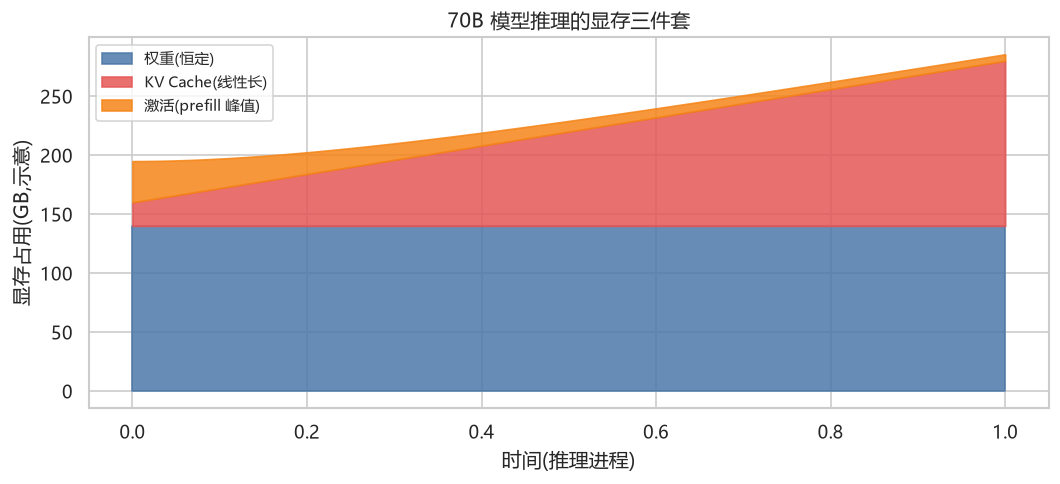

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.2))
t = np.linspace(0, 1, 200)
weight = np.ones_like(t) * 140
kv = 20 + 120 * t
act = 30 * np.exp(-4 * t) + 5
ax.fill_between(t, 0, weight, label="权重(恒定)", color="#4C78A8", alpha=0.85)
ax.fill_between(t, weight, weight + kv, label="KV Cache(线性长)", color="#E45756", alpha=0.85)
ax.fill_between(t, weight + kv, weight + kv + act, label="激活(prefill 峰值)", color="#F58518", alpha=0.85)
ax.set_xlabel("时间(推理进程)"); ax.set_ylabel("显存占用(GB,示意)")
ax.set_title("70B 模型推理的显存三件套", fontsize=12)
ax.legend(frameon=True, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

## 2️⃣ 昇腾 LLM 软件栈 🏗️

昇腾跑 LLM 的“流水线”从上到下:

1. **权重**:safetensors / GGUF / MindIE 自有的格式,可选 FP8 / INT8 压缩;
2. **编译**:MindIE 把模型编译成 MindIE IR(图优化 + 算子融合 + 分页 KV 插入);
3. **运行时**:MindIE LLM Inference 执行连续批处理与采样;
4. **服务**:对外暴露 OpenAI 兼容接口(vLLM-Ascend 则复用 vLLM 的 API Server)。

画成流水线图:

🎨 第 2 步“编译”是昇腾(MindIE)比 GPU 上 eager 执行更深的地方:图级优化在编译期就完成。

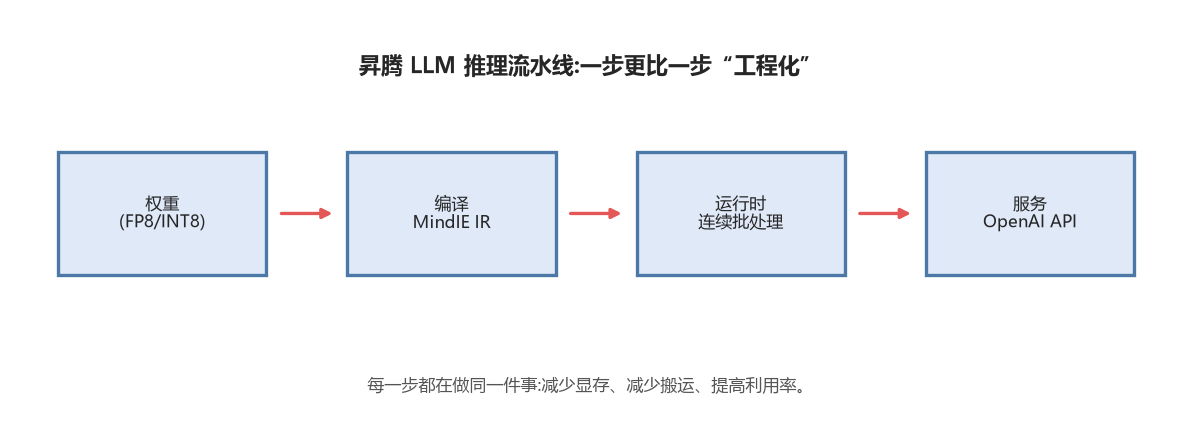

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
stages = ["权重\n(FP8/INT8)", "编译\nMindIE IR", "运行时\n连续批处理", "服务\nOpenAI API"]
xs = [0.04, 0.29, 0.54, 0.79]
for x, s in zip(xs, stages):
    ax.add_patch(plt.Rectangle((x, 0.36), 0.18, 0.3, fc="#DFE9F8", ec="#4C78A8", lw=2))
    ax.text(x + 0.09, 0.51, s, ha="center", va="center", fontsize=10)
for a, b in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(b - 0.01, 0.51), xytext=(a + 0.19, 0.51),
                arrowprops=dict(arrowstyle="-|>", color="#E45756", lw=2))
ax.text(0.5, 0.85, "昇腾 LLM 推理流水线:一步更比一步“工程化”", fontsize=13, ha="center", fontweight="bold")
ax.text(0.5, 0.08, "每一步都在做同一件事:减少显存、减少搬运、提高利用率。", fontsize=10, ha="center", color="#555")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.tight_layout(); plt.show()

## 3️⃣ KV 显存账本:并发 × 长度的线性诅咒 🔢

KV 显存的公式很简单但很扎心:

$$
\text{KV\_GB} = 2(层数\times 注意力头数\times 头维度)\times \text{并发} \times (\text{输入}+\text{输出})
$$

算一笔真实的账(以 32 层、head_dim=128、8 heads 为例):

✅ 并发 128、序列 8192 时,单是 KV 就要 128 GB——这就是为什么必须分页 + 连续批处理。

In [4]:
def kv_cache_gb(layers, num_heads, head_dim, conc, seq):
    return 2.0 * layers * num_heads * head_dim * 2.0 / 1e9 * conc * seq

layers, num_heads, head_dim = 32, 8, 128
print("并发×长度 → KV 显存(GB):")
for conc in [1, 16, 64, 128]:
    for seq in [2048, 8192]:
        g = kv_cache_gb(layers, num_heads, head_dim, conc, seq)
        print(f"  并发 {conc:>4} × 序列 {seq:>5} → {g:8.1f} GB")
print("结论:并发×序列 翻 4 倍,KV 就翻 16 倍——所以 KV 是显存的第一大敌人。")

并发×长度 → KV 显存(GB):
  并发    1 × 序列  2048 →      0.3 GB
  并发    1 × 序列  8192 →      1.1 GB
  并发   16 × 序列  2048 →      4.3 GB
  并发   16 × 序列  8192 →     17.2 GB
  并发   64 × 序列  2048 →     17.2 GB
  并发   64 × 序列  8192 →     68.7 GB
  并发  128 × 序列  2048 →     34.4 GB
  并发  128 × 序列  8192 →    137.4 GB
结论:并发×序列 翻 4 倍,KV 就翻 16 倍——所以 KV 是显存的第一大敌人。


📊 序列 8192 时,并发到 ~48 就顶穿 64GB 单卡——任何引擎都得靠分页与抢占“挤”出空间。

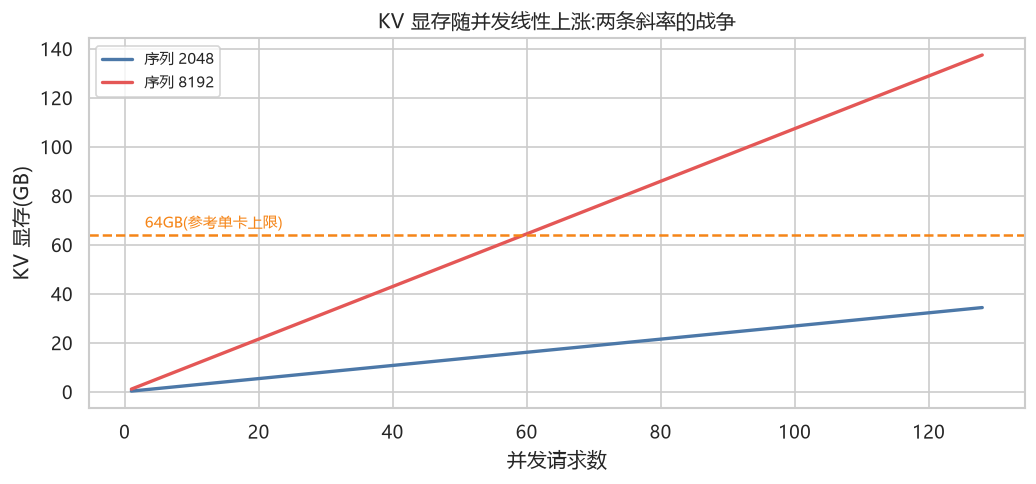

In [5]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
conc_axis = np.arange(1, 129)
for seq in [2048, 8192]:
    gbs = kv_cache_gb(32, 8, 128, conc_axis, seq)
    ax.plot(conc_axis, gbs, label=f"序列 {seq}", lw=2, color="#E45756" if seq == 8192 else "#4C78A8")
ax.axhline(64, color="#F58518", ls="--", lw=1.5)
ax.text(3, 67, "64GB(参考单卡上限)", fontsize=9, color="#F58518")
ax.set_xlabel("并发请求数"); ax.set_ylabel("KV 显存(GB)")
ax.set_title("KV 显存随并发线性上涨:两条斜率的战争", fontsize=12)
ax.legend(frameon=True, fontsize=9)
plt.tight_layout(); plt.show()

## 4️⃣ 连续批处理模拟 🔬

**连续批处理(continuous batching)** 让请求**随时进、随时出**:新请求来了,插进当前批次;
某个请求生成完了,腾出槽位。用 torch 模拟一个“生成槽位池”:

✅ 这就是连续批处理的心跳:加请求、等完成、让槽位、再加请求——引擎的“吞吐机”循环。

In [6]:
class ContinuousBatch:
    def __init__(self, num_slots):
        self.num_slots = num_slots
        self.slots = {}            # 槽位 -> 已生成 token 数

    def add(self, req_id):
        if len(self.slots) < self.num_slots:
            self.slots[req_id] = 0
            return True
        return False

    def step(self, done_ids=()):
        for rid in done_ids:
            self.slots.pop(rid, None)   # 生成完 → 让出槽位

cb = ContinuousBatch(4)
for i in range(6):
    ok = cb.add(f"req{i}")
    print(f"加入 req{i} -> {'成功' if ok else '排队'},当前占用 {len(cb.slots)}/{cb.num_slots}")
cb.step(done_ids=["req0", "req2"])       # 生成完的请求离开
ok = cb.add("req6")
print(f"req0/req2 完成离场,加入 req6 -> {'成功' if ok else '排队'},占用 {len(cb.slots)}/4")
print("连续批处理的意义:槽位不会等整批结束才释放,GPU 时刻满载。")

加入 req0 -> 成功,当前占用 1/4
加入 req1 -> 成功,当前占用 2/4
加入 req2 -> 成功,当前占用 3/4
加入 req3 -> 成功,当前占用 4/4
加入 req4 -> 排队,当前占用 4/4
加入 req5 -> 排队,当前占用 4/4
req0/req2 完成离场,加入 req6 -> 成功,占用 3/4
连续批处理的意义:槽位不会等整批结束才释放,GPU 时刻满载。


## 5️⃣ MoE 与专家并行 🧩

大模型走进 MoE 时代(Mixtral、DeepSeek):一个模型 = 共享主干 + 一堆**专家(expert)**,
每个 token 只激活少量专家。好处:参数量巨大,但每次前向只算一小撮。

昇腾跑 MoE 的关键是 **专家并行(Expert Parallelism, EP)**:把不同专家放到不同卡上,
token 按路由结果发往对应专家所在的卡(All-to-All 通信)。画一张 EP 的路由图:

🎨 MoE 用“稀疏激活”省算力,EP 用“卡间搬家”摊内存——两者配合,千亿参数才能落地。

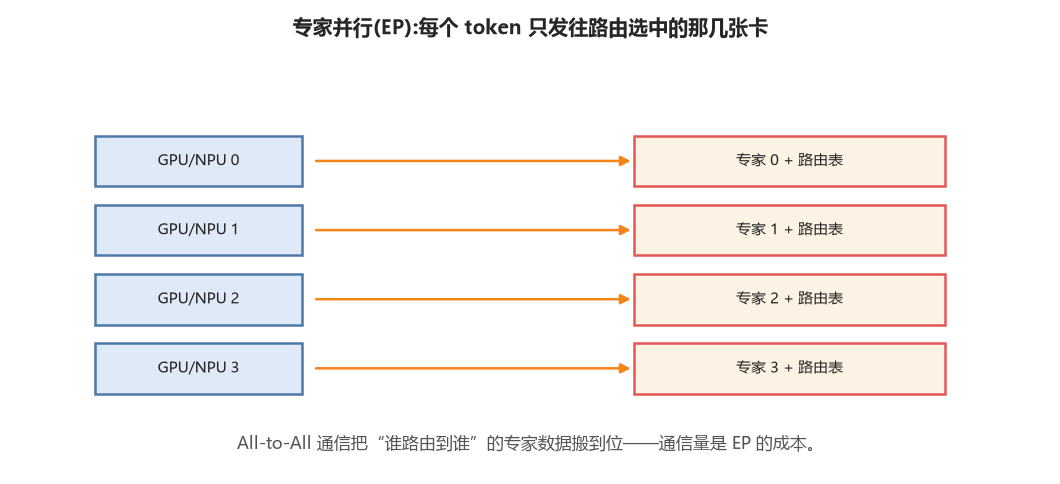

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for i in range(4):
    ax.add_patch(plt.Rectangle((0.08, 0.62 - i * 0.15), 0.2, 0.11, fc="#DFE9F8", ec="#4C78A8", lw=1.5))
    ax.text(0.18, 0.675 - i * 0.15, f"GPU/NPU {i}", ha="center", va="center", fontsize=9)
    ax.add_patch(plt.Rectangle((0.6, 0.62 - i * 0.15), 0.3, 0.11, fc="#FDF3E4", ec="#E45756", lw=1.5))
    ax.text(0.75, 0.675 - i * 0.15, f"专家 {i} + 路由表", ha="center", va="center", fontsize=9)
for i in range(4):
    ax.annotate("", xy=(0.6, 0.675 - i * 0.15), xytext=(0.29, 0.675 - i * 0.15),
                arrowprops=dict(arrowstyle="-|>", color="#F58518", lw=1.5))
ax.text(0.5, 0.95, "专家并行(EP):每个 token 只发往路由选中的那几张卡", fontsize=12, ha="center", fontweight="bold")
ax.text(0.5, 0.05, "All-to-All 通信把“谁路由到谁”的专家数据搬到位——通信量是 EP 的成本。", fontsize=10, ha="center", color="#555")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.tight_layout(); plt.show()

## 6️⃣ 长序列与稀疏注意力 🧭

昇腾把“长序列”当招牌:910C 系列配合 MindIE 可支撑百万 token 级上下文。
方法不是“硬塞”,而是“聪明地少看”:

- **稀疏注意力**:远处 token 用低分辨率窗口,近处细看;
- **KV 压缩 / 丢弃**:把不太重要的历史 KV 挤出缓存;
- **分页 + 抢占**:让长序列与其他请求共享物理块。

画一张“注意力视野”的示意图:

📊 长序列推理的“秘诀”不是全看,而是**有选择地看**——这与人类的阅读方式不谋而合。

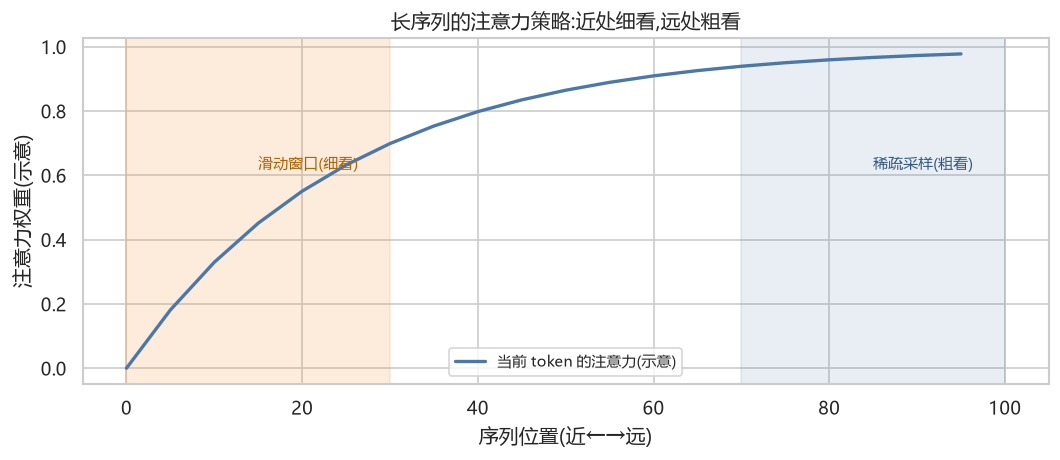

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.0))
pos = np.arange(0, 100, 5)
ax.plot(pos, 1 - np.exp(-pos / 25), color="#4C78A8", lw=2, label="当前 token 的注意力(示意)")
ax.axvspan(0, 30, color="#F58518", alpha=0.15)
ax.axvspan(70, 100, color="#4C78A8", alpha=0.12)
ax.text(15, 0.62, "滑动窗口(细看)", fontsize=9, color="#B06000")
ax.text(85, 0.62, "稀疏采样(粗看)", fontsize=9, color="#31587E")
ax.set_xlabel("序列位置(近←→远)"); ax.set_ylabel("注意力权重(示意)")
ax.set_title("长序列的注意力策略:近处细看,远处粗看", fontsize=12)
ax.legend(frameon=True, fontsize=9)
plt.tight_layout(); plt.show()

## 7️⃣ 配套 Streamlit 演示 🎛️

运行同目录下的 `app_88_ascend_llm.py`,配置**模型规模 / 位宽 / 并发 / 长度**,实时看到
权重与 KV 的显存账本、显存构成饼图,以及 KV 随序列长度的增长曲线:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_88_ascend_llm.py
```

浏览器打开 **http://localhost:8501**。完整源码如下:

📜 这就是 app_88_ascend_llm.py 的完整源码,notebook 与 app 共用同一套显存账本逻辑,保证演示与讲解一致。

In [9]:
%%writefile app_88_ascend_llm.py
# -*- coding: utf-8 -*-
# app_88_ascend_llm.py — 昇腾大模型推理:显存账本与配置 🧮
import numpy as np
import plotly.graph_objects as go
import streamlit as st

st.set_page_config(page_title="🤖 88 · 昇腾大模型推理", layout="wide")
st.title("🤖 第 88 课 · 昇腾大模型推理:显存账本、KV 与连续批处理")

st.markdown("""
昇腾(MindIE / vLLM-Ascend)跑 LLM 的账本,和 GPU 上完全同构:
**模型权重 + KV Cache + 激活/中间量** 三块抢显存。KV Cache 随
`并发 × (输入+输出)长度` 线性增长,所以**连续批处理**与**分页 KV** 缺一不可。
下方配置**模型 / 并发 / 长度 / 位宽**,看显存账本与 KV 占比,并模拟连续批处理如何省显存。
""")

def mem_budget(params, conc, in_len, out_len, bits, d=4096, layers=32):
    w_gb = params * 1e9 * bits / 8 / 1e9
    kv_gb = 2.0 * d * layers * 2.0 / 1e9 * conc * (in_len + out_len) * 0.5
    kv_contig = 2.0 * d * layers * 2.0 / 1e9 * conc * (in_len + out_len)   # 连续预留 ×2
    return w_gb, kv_gb, kv_contig

with st.sidebar:
    st.header("🎛️ 参数")
    params = st.select_slider("模型参数量(B)", options=[7, 13, 32, 70, 130], value=70)
    bits = st.select_slider("权重位宽", options=[16, 8, 4], value=8)
    conc = st.slider("并发请求数", 1, 128, 16, 1)
    in_len = st.slider("平均输入长度(token)", 128, 4096, 1024, 128)
    out_len = st.slider("平均输出长度(token)", 64, 2048, 512, 64)
    st.caption("KV 显存随 并发×(输入+输出) 线性增长;分页让“预留给”变成“按需用”。")

w_gb, kv_gb, kv_contig = mem_budget(params, conc, in_len, out_len, bits)
total = w_gb + kv_gb
c1, c2, c3, c4 = st.columns(4)
c1.metric("权重显存", f"{w_gb:.1f} GB")
c2.metric("KV Cache(分页)", f"{kv_gb:.1f} GB")
c3.metric("KV Cache(连续预留)", f"{kv_contig:.1f} GB")
c4.metric("KV 占权重比例", f"{kv_gb / w_gb * 100:.0f} %")

st.subheader("🥧 显存账本饼图")
fig = go.Figure(go.Pie(labels=["权重", "KV Cache", "激活/中间量"],
                       values=[w_gb, kv_gb, max(total * 0.06, 0.5)],
                       hole=0.42, marker=dict(colors=["#4C78A8", "#E45756", "#F58518"])))
fig.update_layout(title=f"{params}B 模型 · 并发 {conc}:显存构成", height=380,
                  margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)
st.caption("⭐ 并发与长度越大,KV 这块“橙饼”越膨胀——这是服务引擎核心调优的对象。")

st.subheader("📈 KV 显存随长度增长")
L = np.arange(128, in_len + out_len + 1, 128)
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=L, y=[2.0*4096*32*2.0/1e9*conc*l*0.5 for l in L],
                          mode="lines", name="分页按需", line=dict(color="#4C78A8", width=3)))
fig2.add_trace(go.Scatter(x=L, y=[2.0*4096*32*2.0/1e9*conc*l for l in L],
                          mode="lines", name="连续预留(×2)", line=dict(color="#E45756", width=3, dash="dot")))
fig2.update_layout(title="KV Cache 显存随序列长度线性增长(分页 vs 连续预留)",
                   xaxis_title="序列长度(token)", yaxis_title="KV 显存(GB)", height=380,
                   margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig2, use_container_width=True)

st.markdown("""
> 💡 **结论**:昇腾跑 LLM 的“显存三件套”= 权重 + KV + 激活。KV 占比随并发与长度暴涨,
> 于是昇腾引擎和 vLLM 一样拥抱**分页 KV + 连续批处理**。配上 FP8/INT8 低比特权重,
> 70B 级模型才能在单机多卡上舒服地跑起来。
""")
st.caption("《VLLM_learn: 图解 vLLM 推理引擎》第 11 章 · 第 88 课配套演示")

if __name__ == "__main__":
    try:
        import streamlit.runtime as st_runtime
        if st_runtime.exists():
            raise SystemExit(0)
    except Exception:
        pass
    import os, subprocess, sys
    subprocess.run([sys.executable, "-m", "streamlit", "run", os.path.abspath(__file__)])

Overwriting app_88_ascend_llm.py


## ✅ 本课小结

- 昇腾跑 LLM 的显存三件套:权重(恒定)+ KV(线性涨)+ 激活(峰值)
- KV 显存 = 2×层×头×维 × 并发 × 长度,并发与长度是最大的放大因子
- 连续批处理让请求随时进出,GPU/NPU 时刻满载
- MoE 用稀疏激活省算力,专家并行(EP)用卡间通信摊内存
- 长序列靠稀疏注意力、KV 压缩与分页硬扛到百万 token 级

## ✍️ 动手练习

1. 把 ContinuousBatch 加一个“等待队列”,槽位空出时自动补位,打印占用曲线
2. 估算 70B、32 层、8 头模型在并发 256、序列 4096 时的 KV 显存,验证是否爆卡
3. 给 EP 画一张“通信量随专家数变化”的曲线(专家越多,单跳通信越小但 hops 越多)
4. 调研 DeepSeek MoE 的 EP 实践与 vllm-ascend 的 EP 支持,对比实现要点

## 🔗 延伸阅读

- [MindIE 推理引擎](https://www.hiascend.com/zh/developer/techarticles)
- [vLLM-Ascend 支持矩阵](https://docs.vllm.ai/projects/ascend/en/latest/user_guide/support_matrix/)
- [Mixtral MoE 论文](https://arxiv.org/abs/2401.04088)

---
> 🎉 恭喜完成本课!下一课见!